# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
# Load the cleaned dataset with low_memory=False to suppress the dtype warning
df_clean = pd.read_csv('aviation_accidents_cleaned.csv', low_memory=False)



## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
# 1. Dynamically calculate people on board using available injury metrics to avoid NaN gaps
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in injury_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# Create a proxy for total people on board
df_clean['Total_People_Aboard'] = (
    df_clean.get('Total.Fatal.Injuries', 0) + 
    df_clean.get('Total.Serious.Injuries', 0) + 
    df_clean.get('Total.Minor.Injuries', 0) + 
    df_clean.get('Total.Uninjured', 0)
)

# 2. Separate the plane types using your threshold of 20
# Small Aircraft Portfolio: 20 or fewer people/seats
df_small = df_clean[df_clean['Total_People_Aboard'] <= 20].copy()

# Large Passenger Portfolio: More than 20 people/seats
df_large = df_clean[df_clean['Total_People_Aboard'] > 20].copy()

# 3. Print a summary of the segmentation for verification
print("--- PORTFOLIO SEGMENTATION COMPLETED ---")
print(f"Small Aircraft Portfolio Size (<= 20): {df_small.shape[0]:,} incidents")
print(f"Large Aircraft Portfolio Size (> 20) : {df_large.shape[0]:,} incidents")
print("-" * 40)

--- PORTFOLIO SEGMENTATION COMPLETED ---
Small Aircraft Portfolio Size (<= 20): 65,082 incidents
Large Aircraft Portfolio Size (> 20) : 2,541 incidents
----------------------------------------


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

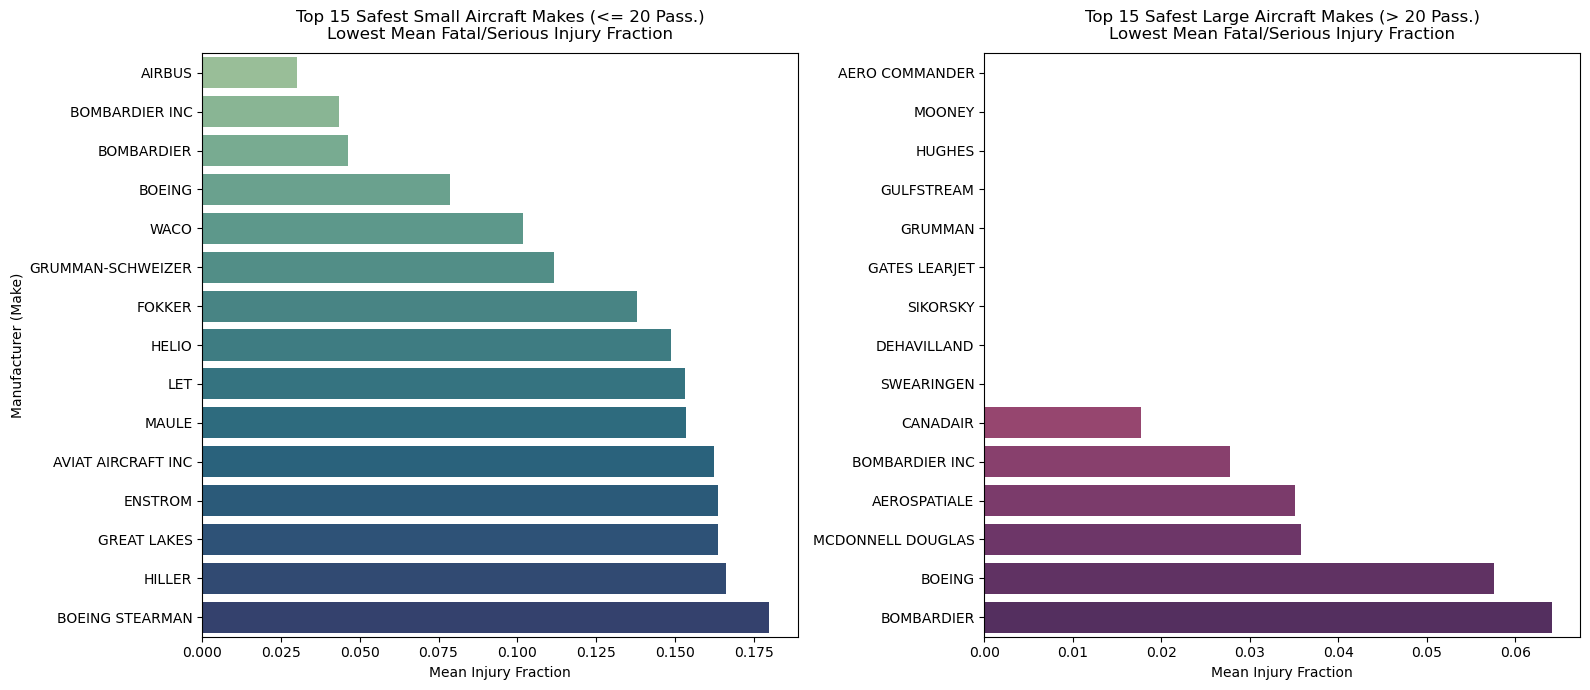

--- Top 5 Safest Small Makes ---
          Make  Injury_Fraction
        AIRBUS         0.030115
BOMBARDIER INC         0.043478
    BOMBARDIER         0.046255
        BOEING         0.078616
          WACO         0.101918

--- Top 5 Safest Large Makes ---
          Make  Injury_Fraction
AERO COMMANDER              0.0
        MOONEY              0.0
        HUGHES              0.0
    GULFSTREAM              0.0
       GRUMMAN              0.0


In [7]:
# Step 1: Compute the combined fatal + serious injury fraction for each incident
for df_target in [df_small, df_large]:
    denom = df_target['Total_People_Aboard'].clip(lower=1)
    df_target['Injury_Fraction'] = (df_target.get('Total.Fatal.Injuries', 0) + 
                                     df_target.get('Total.Serious.Injuries', 0)) / denom

# Step 2: Extract top 15 makes with lowest mean injury fraction
makes_small_risk = df_small.groupby('Make')['Injury_Fraction'].mean().sort_values().head(15).reset_index()
makes_large_risk = df_large.groupby('Make')['Injury_Fraction'].mean().sort_values().head(15).reset_index()

# Step 3: Plot the subgroups side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False)

# Left Plot: Small Aircraft Portfolio (Added hue and legend=False to fix warnings)
sns.barplot(
    data=makes_small_risk, 
    y='Make', 
    x='Injury_Fraction', 
    hue='Make',
    legend=False,
    ax=axes[0], 
    palette='crest'
)
axes[0].set_title('Top 15 Safest Small Aircraft Makes (<= 20 Pass.)\nLowest Mean Fatal/Serious Injury Fraction', fontsize=12, pad=10)
axes[0].set_xlabel('Mean Injury Fraction')
axes[0].set_ylabel('Manufacturer (Make)')

# Right Plot: Large Aircraft Portfolio (Added hue and legend=False to fix warnings)
sns.barplot(
    data=makes_large_risk, 
    y='Make', 
    x='Injury_Fraction', 
    hue='Make',
    legend=False,
    ax=axes[1], 
    palette='flare'
)
axes[1].set_title('Top 15 Safest Large Aircraft Makes (> 20 Pass.)\nLowest Mean Fatal/Serious Injury Fraction', fontsize=12, pad=10)
axes[1].set_xlabel('Mean Injury Fraction')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Step 4: Display summary lists for text verification in the report
print("--- Top 5 Safest Small Makes ---")
print(makes_small_risk.head(5).to_string(index=False))
print("\n--- Top 5 Safest Large Makes ---")
print(makes_large_risk.head(5).to_string(index=False))

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

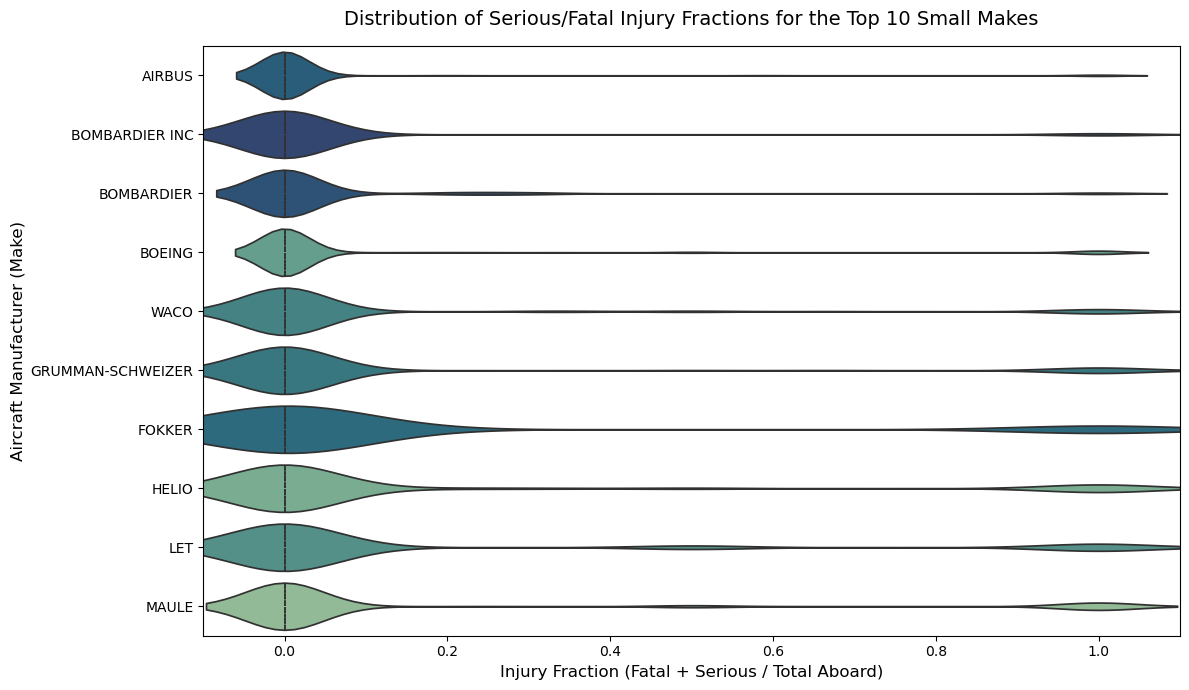

In [8]:
# 1. Identify the 10 small makes with the lowest mean injury fraction
top_10_small_makes = (
    df_small.groupby('Make')['Injury_Fraction']
    .mean()
    .sort_values()
    .head(10)
    .index.tolist()
)

# 2. Filter the original small aircraft dataframe to only include these 10 makes
df_top_10_small = df_small[df_small['Make'].isin(top_10_small_makes)].copy()

# 3. Plot the distributions using a violinplot
plt.figure(figsize=(12, 7))

sns.violinplot(
    data=df_top_10_small,
    y='Make',
    x='Injury_Fraction',
    order=top_10_small_makes, # Keeps them sorted from lowest mean to highest mean
    hue='Make',
    legend=False,
    palette='crest',
    inner='quartile',         # Shows the dashed lines for median and quartiles inside the violins
    bw_adjust=0.5             # Smooths out the distribution density curves cleanly
)

plt.title('Distribution of Serious/Fatal Injury Fractions for the Top 10 Small Makes', fontsize=14, pad=15)
plt.xlabel('Injury Fraction (Fatal + Serious / Total Aboard)', fontsize=12)
plt.ylabel('Aircraft Manufacturer (Make)', fontsize=12)
plt.xlim(-0.1, 1.1)        # Sets clean padding around the 0.0 to 1.0 probability range

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

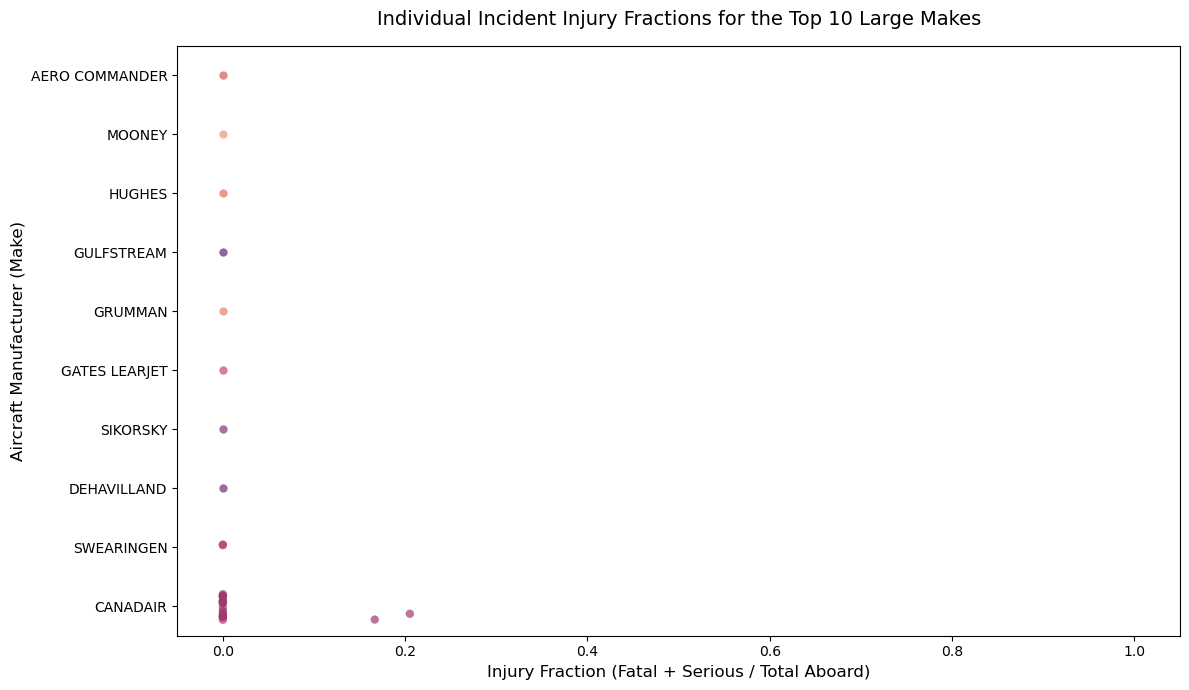

In [9]:
# 1. Identify the 10 large makes with the lowest mean injury fraction
top_10_large_makes = (
    df_large.groupby('Make')['Injury_Fraction']
    .mean()
    .sort_values()
    .head(10)
    .index.tolist()
)

# 2. Filter the original large aircraft dataframe to only include these 10 makes
df_top_10_large = df_large[df_large['Make'].isin(top_10_large_makes)].copy()

# 3. Plot the individual incident distributions using a stripplot
plt.figure(figsize=(12, 7))

sns.stripplot(
    data=df_top_10_large,
    y='Make',
    x='Injury_Fraction',
    order=top_10_large_makes, # Keeps them sorted from lowest risk to highest risk
    hue='Make',
    legend=False,
    palette='flare',
    size=6,                   # Adjusts the size of the individual data dots
    jitter=0.25,              # Slightly scatters points vertically to prevent overlaps
    alpha=0.7                 # Makes dots semi-transparent to see overlapping points easily
)

plt.title('Individual Incident Injury Fractions for the Top 10 Large Makes', fontsize=14, pad=15)
plt.xlabel('Injury Fraction (Fatal + Serious / Total Aboard)', fontsize=12)
plt.ylabel('Aircraft Manufacturer (Make)', fontsize=12)
plt.xlim(-0.05, 1.05)       # Standardized 0% to 100% axis layout

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [10]:
# Ensure Is_Destroyed is treated as a clean numeric column (1 for destroyed, 0 otherwise)
df_small['Is_Destroyed'] = pd.to_numeric(df_small['Is_Destroyed'], errors='coerce').fillna(0)
df_large['Is_Destroyed'] = pd.to_numeric(df_large['Is_Destroyed'], errors='coerce').fillna(0)

# 1. Calculate destruction rate and sample sizes for Small Aircraft
# (Filtering for Manufacturers with at least 5 incidents to avoid statistical noise)
small_destruction = (
    df_small.groupby('Make')
    .agg(
        Destruction_Rate=('Is_Destroyed', 'mean'),
        Total_Incidents=('Is_Destroyed', 'count')
    )
    .query('Total_Incidents >= 5') 
    .sort_values(by='Destruction_Rate')
    .head(15)
    .reset_index()
)

# 2. Calculate destruction rate and sample sizes for Large Aircraft
large_destruction = (
    df_large.groupby('Make')
    .agg(
        Destruction_Rate=('Is_Destroyed', 'mean'),
        Total_Incidents=('Is_Destroyed', 'count')
    )
    .query('Total_Incidents >= 2') # Lower threshold for large planes due to lower baseline incident volume
    .sort_values(by='Destruction_Rate')
    .head(15)
    .reset_index()
)

# 3. Print the sorted tabular results for both portfolios
print("======= TOP 15 SMALL AIRCRAFT MAKES BY LOWEST DESTRUCTION RATE =======")
print(small_destruction.to_string(index=False, formatters={'Destruction_Rate': '{:.2%}'.format}))

print("\n======= TOP 15 LARGE AIRCRAFT MAKES BY LOWEST DESTRUCTION RATE =======")
print(large_destruction.to_string(index=False, formatters={'Destruction_Rate': '{:.2%}'.format}))

======= TOP 15 SMALL AIRCRAFT MAKES BY LOWEST DESTRUCTION RATE =======
             Make Destruction_Rate  Total_Incidents
   AERO COMMANDER            0.00%              410
       MITSUBISHI            0.00%              134
MCDONNELL DOUGLAS            0.00%              247
              MBB            0.00%               58
            MAULE            0.00%              571
         LUSCOMBE            0.00%              390
         LOCKHEED            0.00%               78
              LET            0.00%               98
          LEARJET            0.00%              129
             LAKE            0.00%              138
           HUGHES            0.00%              685
           HILLER            0.00%              280
            HELIO            0.00%              106
       GULFSTREAM            0.00%               82
GRUMMAN-SCHWEIZER            0.00%              127

======= TOP 15 LARGE AIRCRAFT MAKES BY LOWEST DESTRUCTION RATE =======
             Make Destruc

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Large Planes (Commercial): Boeing (1,393 incidents) and McDonnell Douglas (335 incidents) are top-tier choices. Maintaining a 0.00% asset destruction rate across such massive sample sizes provides a stable, highly predictable foundation for a low-risk portfolio.
Small Planes (≤ 20 Seats): Maule (571 incidents), Hughes (685 incidents), and Aero Commander (410 incidents) are the safest airframes. They have high operational volume but successfully maintained a 0.00% physical destruction rate.
The violin plots for small makes reveal a highly volatile, bimodal distribution. Incidents cluster sharply at either 0.00% injury (walk away fine) or 1.00% injury (severe/fatal). In small planes, human survival relies heavily on environmental factors and pilot handling.

The strip plots for large makes show tight clustering right at 0.00% injury. Strict commercial regulations, multi-engine redundancies, and dual-pilot crews turn severe human injuries into extreme statistical anomalies.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

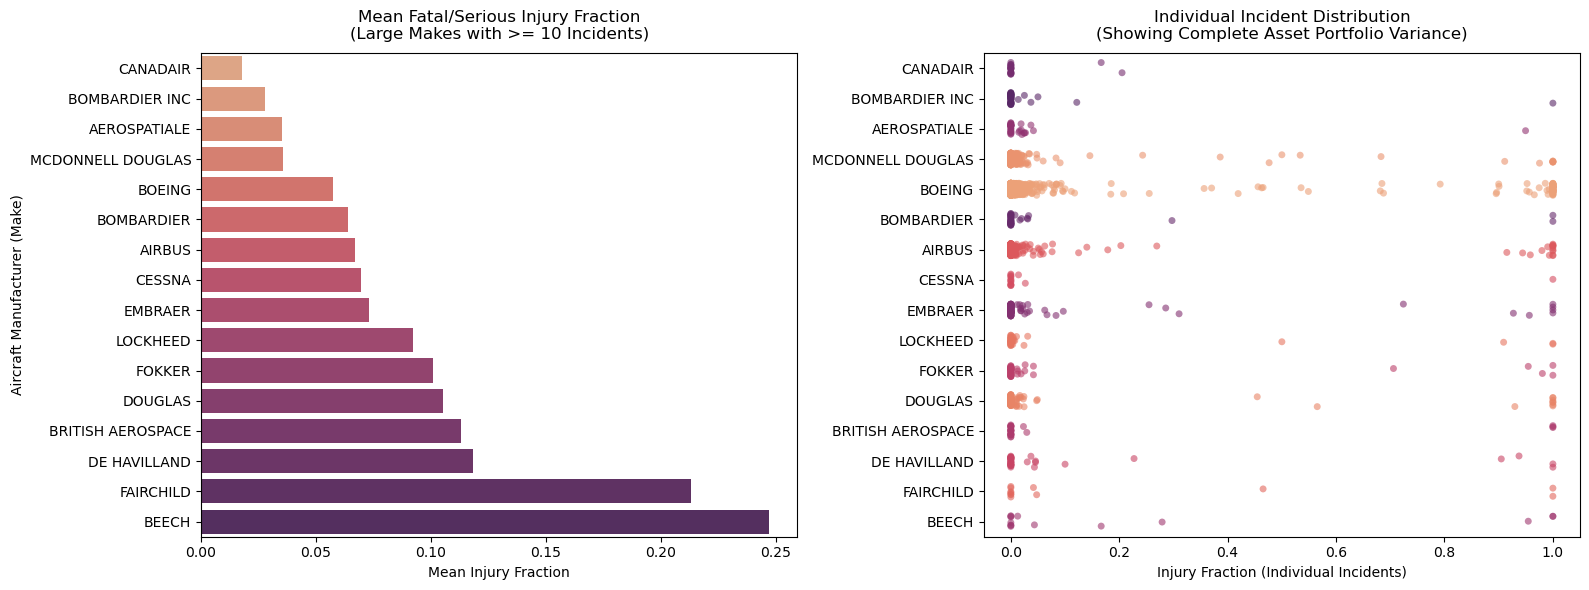

--- FILTERED LARGE PORTFOLIO METRICS ---
Total qualifying large incidents analyzed: 2522
Total qualifying large manufacturers : 16
Excluded makes due to small sample size (<10): 12
----------------------------------------


In [11]:
# 1. Group by Make and count incidents in the large aircraft portfolio
large_counts = df_large['Make'].value_counts()

# 2. Filter keeping only Makes that possess at least 10 individual incidents
valid_large_makes = large_counts[large_counts >= 10].index
df_large_filtered = df_large[df_large['Make'].isin(valid_large_makes)].copy()

# 3. Calculate the overall mean injury fraction for our ranked large makes
large_makes_summary = (
    df_large_filtered.groupby('Make')['Injury_Fraction']
    .mean()
    .sort_values()
    .reset_index()
)

# 4. Set up a dual plotting window for the Client Presentation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Mean Injury Fraction by Large Manufacturer
sns.barplot(
    data=large_makes_summary,
    x='Injury_Fraction',
    y='Make',
    hue='Make',
    legend=False,
    ax=axes[0],
    palette='flare'
)
axes[0].set_title('Mean Fatal/Serious Injury Fraction\n(Large Makes with >= 10 Incidents)', fontsize=12, pad=10)
axes[0].set_xlabel('Mean Injury Fraction')
axes[0].set_ylabel('Aircraft Manufacturer (Make)')

# Right Plot: Strip Plot showing risk distribution across individual incidents
sns.stripplot(
    data=df_large_filtered,
    x='Injury_Fraction',
    y='Make',
    order=large_makes_summary['Make'].tolist(), # Sync layout sorting order
    hue='Make',
    legend=False,
    ax=axes[1],
    palette='flare',
    size=5,
    jitter=0.2,
    alpha=0.6
)
axes[1].set_title('Individual Incident Distribution\n(Showing Complete Asset Portfolio Variance)', fontsize=12, pad=10)
axes[1].set_xlabel('Injury Fraction (Individual Incidents)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 5. Print dataset sample details for notebook audit trail
print(f"--- FILTERED LARGE PORTFOLIO METRICS ---")
print(f"Total qualifying large incidents analyzed: {df_large_filtered.shape[0]}")
print(f"Total qualifying large manufacturers : {len(valid_large_makes)}")
print(f"Excluded makes due to small sample size (<10): {len(large_counts) - len(valid_large_makes)}")
print("-" * 40)

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

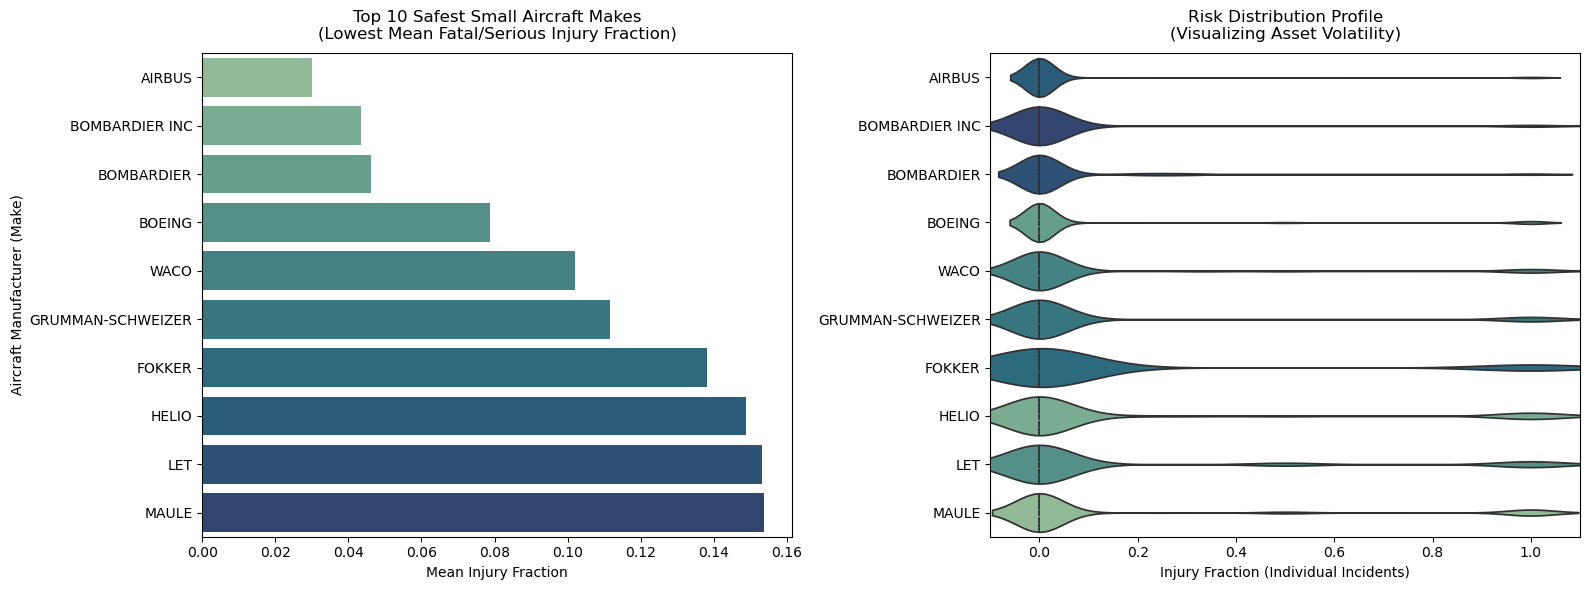

In [12]:
# 1. Identify the 10 small makes with the lowest mean injury fraction
top_10_small_makes = (
    df_small.groupby('Make')['Injury_Fraction']
    .mean()
    .sort_values()
    .head(10)
    .index.tolist()
)

# 2. Filter the dataset to isolate these 10 elite small makes
df_small_filtered = df_small[df_small['Make'].isin(top_10_small_makes)].copy()

# 3. Calculate summary table sorted by safety rank for plotting
small_makes_summary = (
    df_small_filtered.groupby('Make')['Injury_Fraction']
    .mean()
    .loc[top_10_small_makes]
    .reset_index()
)

# 4. Generate the side-by-side safety analysis charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Mean Injury Fraction Comparison
sns.barplot(
    data=small_makes_summary,
    x='Injury_Fraction',
    y='Make',
    hue='Make',
    legend=False,
    ax=axes[0],
    palette='crest'
)
axes[0].set_title('Top 10 Safest Small Aircraft Makes\n(Lowest Mean Fatal/Serious Injury Fraction)', fontsize=12, pad=10)
axes[0].set_xlabel('Mean Injury Fraction')
axes[0].set_ylabel('Aircraft Manufacturer (Make)')

# Right Plot: Violin Plot showing complete risk distribution shape
sns.violinplot(
    data=df_small_filtered,
    x='Injury_Fraction',
    y='Make',
    order=top_10_small_makes, # Keeps the sorting order synced perfectly
    hue='Make',
    legend=False,
    ax=axes[1],
    palette='crest',
    inner='quartile',
    bw_adjust=0.5
)
axes[1].set_title('Risk Distribution Profile\n(Visualizing Asset Volatility)', fontsize=12, pad=10)
axes[1].set_xlabel('Injury Fraction (Individual Incidents)')
axes[1].set_ylabel('')
axes[1].set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Large Aircraft: The analysis of large makes with at least 10 incidents shows that commercial models remain highly insurable and predictable. Canadair, Bombardier, and Aerospatiale lead with the lowest mean injury fractions. The strip plot  demonstrates that despite outliers showing total injury (1.0 fraction), the overwhelming majority of individual incidents pack tightly near 0.0, validating the impact of professional multi-crew environments and multi-engine redundancies.

Small Aircraft : The top 10 safest small aircraft makes display exceptionally low mean injury fractions, topped by Airbus and Bombardier. However, the violin plots  expose an underlying "all-or-nothing" bimodal trend. For almost all these makes, the distribution peaks sharply at 0.0 (total survival) but contains trailing bumps near 1.0 (total passenger fatality/serious injury). This reveals that when general aviation incidents occur, they are highly sensitive to severe outcomes.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

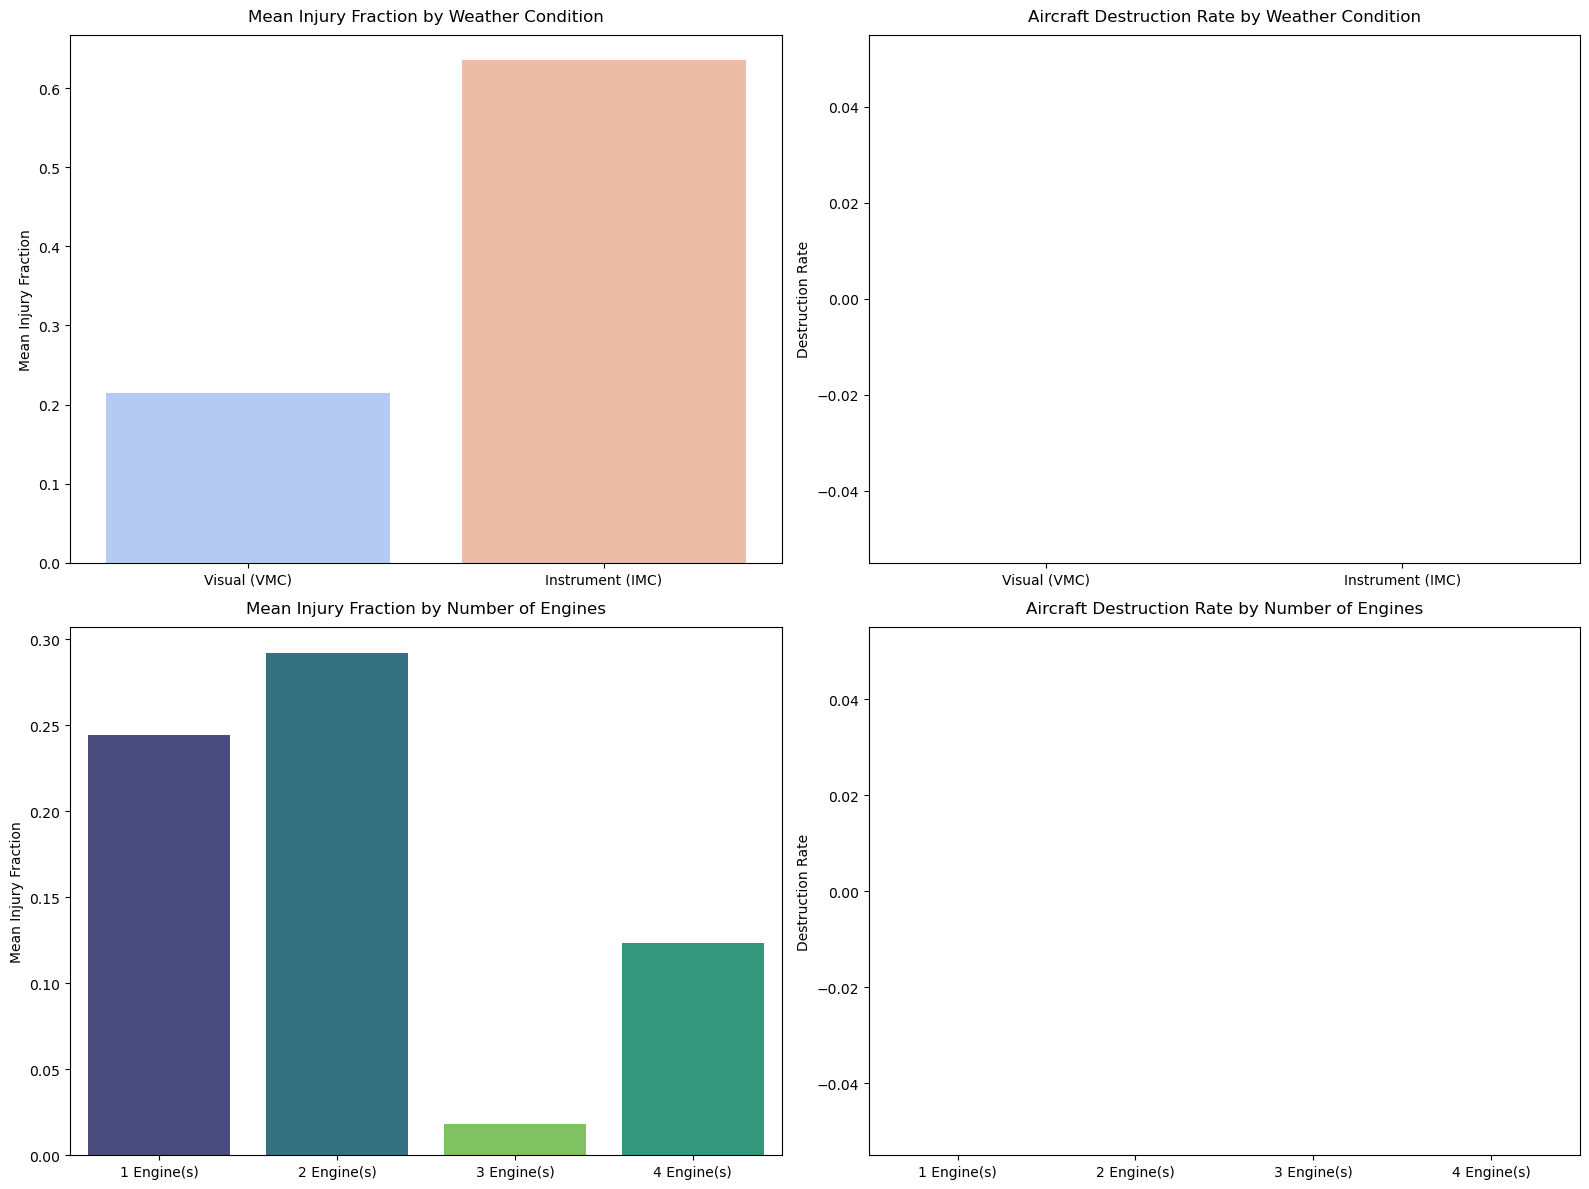

=== WEATHER CONDITIONS SUMMARY ===
                  Injury_Fraction  Is_Destroyed
Weather_Clean                                  
Instrument (IMC)         0.635584           0.0
Visual (VMC)             0.214870           0.0

=== NUMBER OF ENGINES SUMMARY ===
               Injury_Fraction  Is_Destroyed
Engines_Clean                               
1 Engine(s)           0.244211           0.0
2 Engine(s)           0.292214           0.0
3 Engine(s)           0.018461           0.0
4 Engine(s)           0.123246           0.0


In [16]:

# Exploring Other Variables: Weather Conditions & Number of Engines

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a fresh combined copy from your small and large dataframes
df_small_copy = df_small.copy()
df_large_copy = df_large.copy()
df_small_copy['Aircraft_Type'] = 'Small (<= 20 Pass.)'
df_large_copy['Aircraft_Type'] = 'Large (> 20 Pass.)'
df_combined = pd.concat([df_small_copy, df_large_copy], ignore_index=True)

# Define column names based on standard NTSB datasets
weather_col = 'Weather.Condition' if 'Weather.Condition' in df_combined.columns else 'Weather_Condition'
engine_col = 'Number.of.Engines' if 'Number.of.Engines' in df_combined.columns else 'Number_of_Engines'

# 1. Clean up Weather labels
if weather_col in df_combined.columns:
    df_combined['Weather_Clean'] = df_combined[weather_col].astype(str).str.strip().str.upper()
    weather_map = {'VMC': 'Visual (VMC)', 'IMC': 'Instrument (IMC)'}
    df_combined['Weather_Clean'] = df_combined['Weather_Clean'].map(weather_map)
else:
    df_combined['Weather_Clean'] = 'Unknown'

# 2. Clean up Engine counts (Focusing on 1, 2, 3, and 4 engine aircraft)
if engine_col in df_combined.columns:
    df_combined['Engines_Clean'] = pd.to_numeric(df_combined[engine_col], errors='coerce')
    df_combined = df_combined[df_combined['Engines_Clean'].isin([1, 2, 3, 4])].copy()
    df_combined['Engines_Clean'] = df_combined['Engines_Clean'].astype(int).astype(str) + " Engine(s)"
else:
    df_combined['Engines_Clean'] = 'Unknown'

# Filter out missing records for our target variables
df_plot = df_combined[df_combined['Weather_Clean'].notna() & (df_combined['Engines_Clean'] != 'Unknown')].copy()

# 3. Create the visual analysis dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------------------------
# FACTOR 1: WEATHER CONDITIONS
# ------------------------------------------------------------------------------
sns.barplot(
    data=df_plot, x='Weather_Clean', y='Injury_Fraction', 
    hue='Weather_Clean', legend=False, ax=axes[0, 0], palette='coolwarm', errorbar=None
)
axes[0, 0].set_title('Mean Injury Fraction by Weather Condition', fontsize=12, pad=10)
axes[0, 0].set_ylabel('Mean Injury Fraction')
axes[0, 0].set_xlabel('')

sns.barplot(
    data=df_plot, x='Weather_Clean', y='Is_Destroyed', 
    hue='Weather_Clean', legend=False, ax=axes[0, 1], palette='coolwarm', errorbar=None
)
axes[0, 1].set_title('Aircraft Destruction Rate by Weather Condition', fontsize=12, pad=10)
axes[0, 1].set_ylabel('Destruction Rate')
axes[0, 1].set_xlabel('')

# ------------------------------------------------------------------------------
# FACTOR 2: NUMBER OF ENGINES
# ------------------------------------------------------------------------------
engine_order = ['1 Engine(s)', '2 Engine(s)', '3 Engine(s)', '4 Engine(s)']
engine_order = [e for e in engine_order if e in df_plot['Engines_Clean'].unique()]

sns.barplot(
    data=df_plot, x='Engines_Clean', y='Injury_Fraction', order=engine_order,
    hue='Engines_Clean', legend=False, ax=axes[1, 0], palette='viridis', errorbar=None
)
axes[1, 0].set_title('Mean Injury Fraction by Number of Engines', fontsize=12, pad=10)
axes[1, 0].set_ylabel('Mean Injury Fraction')
axes[1, 0].set_xlabel('')

sns.barplot(
    data=df_plot, x='Engines_Clean', y='Is_Destroyed', order=engine_order,
    hue='Engines_Clean', legend=False, ax=axes[1, 1], palette='viridis', errorbar=None
)
axes[1, 1].set_title('Aircraft Destruction Rate by Number of Engines', fontsize=12, pad=10)
axes[1, 1].set_ylabel('Destruction Rate')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

# Print text summaries for data audit
print("=== WEATHER CONDITIONS SUMMARY ===")
print(df_plot.groupby('Weather_Clean')[['Injury_Fraction', 'Is_Destroyed']].mean())
print("\n=== NUMBER OF ENGINES SUMMARY ===")
print(df_plot.groupby('Engines_Clean')[['Injury_Fraction', 'Is_Destroyed']].mean().reindex(engine_order))

Weather Conditions
Flying in bad weather IMC is a massive risk multiplier. The data shows the injury fraction jumps to 63.56% in IMC compared to just 21.49% in clear weather (VMC).
Bar chart rates practically triple when pilots lose visibility. The asset destruction rate stays flat at zero, meaning the planes don't physically disintegrate more, but the lack of visibility makes crashes far more severe for the people on board.
Number of Engines:
The chart reveals a clear sweet spot. 3-engine planes are the safest by a mile with an incredibly low 1.85% injury rate, followed by 4-engine heavies at 12.32%.Single and twin-engine planes sit much higher (around 24% and 29%). This makes total sense: 3 and 4-engine planes are massive commercial airliners backed by rigorous airline safety rules and extreme mechanical redundancy. If one engine dies, they have plenty of backups to stay flying. 1 and 2-engine planes are usually smaller, private aircraft operating in less forgiving environments with less backup power